# AdaBoost: Margin Improvement and Weight Concentration

Boosting combines weak learners into a strong classifier by repeatedly reweighting samples.
At each round, difficult points get larger weights:
$$
w_i^{(t+1)} \propto w_i^{(t)}\exp\!\left(-\alpha_t y_i h_t(x_i)\right).
$$
We show how sample weights concentrate over iterations and how decision boundaries improve.


## Synthetic dataset and weak stump dictionary


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

n = 220
X = rng.uniform(-1, 1, size=(n, 2))
y = np.sign(X[:, 0]**2 + 0.4*X[:, 1] - 0.2 + 0.25*rng.normal(size=n))
y[y == 0] = 1

ths = np.linspace(-1, 1, 35)
stumps = []
for j in [0, 1]:
    for th in ths:
        for s in [-1, 1]:
            stumps.append((j, th, s))

def stump_pred(X, j, th, s):
    return s * np.where(X[:, j] >= th, 1, -1)


## AdaBoost optimization and weight snapshots


In [2]:
T = 45
w = np.ones(n) / n
alphas = []
chosen = []
w_hist = [w.copy()]

for t in range(T):
    best = None
    best_err = 1.0
    best_h = None
    for j, th, s in stumps:
        h = stump_pred(X, j, th, s)
        err = np.sum(w[h != y])
        if err < best_err:
            best_err = err
            best = (j, th, s)
            best_h = h
    err = np.clip(best_err, 1e-8, 1 - 1e-8)
    alpha = 0.5 * np.log((1 - err) / err)
    w = w * np.exp(-alpha * y * best_h)
    w = w / w.sum()
    chosen.append(best)
    alphas.append(alpha)
    w_hist.append(w.copy())

def score_grid(xg, yg, t):
    P = np.c_[xg.ravel(), yg.ravel()]
    F = np.zeros(len(P))
    for k in range(t):
        j, th, s = chosen[k]
        F += alphas[k] * stump_pred(P, j, th, s)
    return F.reshape(xg.shape)

xx = np.linspace(-1, 1, 260)
yy = np.linspace(-1, 1, 260)
XX, YY = np.meshgrid(xx, yy)


## Weight concentration at four times and final boundary


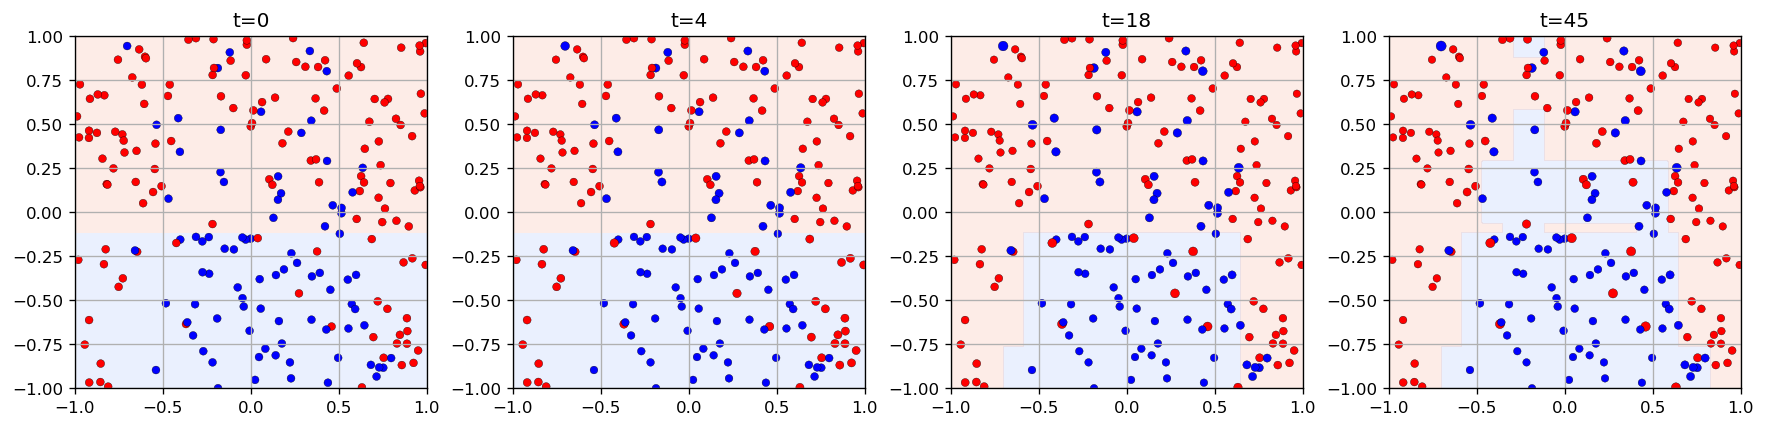

In [3]:
times = [0, 4, 18, T]
fig, axes = plt.subplots(1, 4, figsize=(14.6, 3.6), constrained_layout=True)
for ax, t in zip(axes, times):
    wt = w_hist[t]
    F = score_grid(XX, YY, max(t, 1))
    ax.contourf(XX, YY, np.sign(F), levels=[-2, 0, 2], cmap="coolwarm", alpha=0.18)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=20 + 520*wt, edgecolors="k", linewidths=0.2)
    ax.set_title(f"t={t}")
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive: choose boosting round
